# 牙齿全景 X 光片实例分割实验：原始复现版本

本 notebook 尽量保持与原始 notes/论文训练设置一致，用作复现实验基线。实验比较 Active Contour、U-Net 和加入 YOLO 边界框先验的 OralBBNet，任务目标是预测 32 个 FDI 牙位通道的实例 mask。


## 运行环境

依赖：

```bash
pip install numpy pandas matplotlib pillow tifffile scikit-image scikit-learn opencv-python tensorflow
```

YOLO 先验直接由数据集中的 `.txt` 标签生成，不额外训练 YOLO 模型。


In [1]:
import os
# 设置可见 GPU；修改后需重启 kernel
GPU_IDS = "1,2"
if GPU_IDS is not None:
    os.environ["CUDA_VISIBLE_DEVICES"] = GPU_IDS
print("CUDA_VISIBLE_DEVICES=", os.environ.get("CUDA_VISIBLE_DEVICES", "not set; using all visible GPUs"))

# Python 标准库
import random
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

# 图像读取、处理与可视化
from IPython.display import display
from PIL import Image
import cv2
import pandas as pd
import tifffile as tiff

# 深度学习与评估工具
import keras
import numpy as np
import tensorflow as tf
from keras import layers
from matplotlib import pyplot as plt
from skimage import exposure, filters, measure, morphology, segmentation
from sklearn.model_selection import train_test_split

# 基础路径在下一节统一配置
ROOT = Path.cwd()
DATA_ROOT = ROOT / "Dataset" / "bb_u_net_dataset"
YOLO_ROOT = ROOT / "Dataset" / "yolo_train_dataset"
YOLO_TEST_ROOT = ROOT / "Dataset" / "yolo_test_dataset"


CUDA_VISIBLE_DEVICES= 1,2


I0000 00:00:1779688583.184446 3507647 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 实验配置

配置按论文训练细节和 `notebooks/` 原始代码对齐：512×512 输入、64-1024 U-Net、dropout=0.12、softmax 输出、Adam(lr=3e-4, beta1=0.99)、Dice+L2 loss、λ=0.1、epochs=60、固定阈值评估。除 GPU 可见设备和显存相关执行方式外，不在本 notebook 中加入改进版 loss 或调参策略。

两张 GPU 时每卡 `PHYSICAL_BATCH_SIZE=1`，全局 batch size 为 2，与原始 notes 的 batch=2 对齐；单卡运行时可用梯度累积 2 步保持等效 batch size。数据按类别顺序划分为 340 张 train pool 和 85 张 test，并从 train pool 中划出 valid 用于学习率衰减。


In [2]:
NOTEBOOK_ROOT = Path.cwd()
# 兼容从项目根目录或 Instance_seg_teeth 运行
if (NOTEBOOK_ROOT / "Dataset").exists():
    DATA_ROOT = NOTEBOOK_ROOT / "Dataset"
elif (NOTEBOOK_ROOT / "Instance_seg_teeth" / "Dataset").exists():
    DATA_ROOT = NOTEBOOK_ROOT / "Instance_seg_teeth" / "Dataset"
else:
    DATA_ROOT = NOTEBOOK_ROOT / "Dataset"

BB_UNET_ROOT = DATA_ROOT / "bb_u_net_dataset"
YOLO_ROOT = DATA_ROOT / "yolo_train_dataset"
YOLO_TEST_ROOT = DATA_ROOT / "yolo_test_dataset"
RESULTS_DIR = NOTEBOOK_ROOT / "results_original"
CACHE_DIR = NOTEBOOK_ROOT / "cache"
CHECKPOINT_DIR = RESULTS_DIR / "checkpoints"

# ---------- 实验参数 ----------
IMAGE_SIZE = (512, 512)        # 统一输入尺寸 (H, W)
EPOCHS = 60                    # 与 notebooks 目录中的原始训练轮数一致
BATCH_SIZE = 2                 # 原始代码/论文的目标 batch size
PHYSICAL_BATCH_SIZE = 1        # 单卡显存不足时每步实际 batch；显存足够可改为 2
ACCUMULATION_STEPS = max(1, BATCH_SIZE // PHYSICAL_BATCH_SIZE)
USE_MIRRORED_STRATEGY = True   # 多卡加速；如需严格单卡复现可改为 False
BASE_FILTERS = 64              # 与原始 notebooks 的 U-Net 宽度一致
LEARNING_RATE = 3e-4           # Adam learning rate
ADAM_BETA_1 = 0.99             # 论文中 momentum=0.99，对应 Adam beta_1
PRED_THRESHOLD = 0.5           # 预测二值化阈值
TRAIN_AUGMENT_FLIPS = True     # 水平和垂直翻转增强
YOLO_CONF_THRESHOLD = 0.5
YOLO_IOU_THRESHOLD = 0.5
SEED = 42                  # 固定随机种子，保证划分和训练过程可复现

# 原始 notebooks 的类别顺序和数量
CATEGORY_ORDER = [f"cate{i}" for i in range(1, 11)]
CATEGORY_COUNTS = [24, 72, 15, 32, 37, 30, 33, 140, 7, 35]
TEST_FRACTION_PER_CATEGORY = 0.20
VALID_FRACTION_FROM_REMAINING = 0.10

# FDI 牙位编号到模型输出通道的映射
OUTPUT_CHANNELS = 32
TOOTH_ORDER = [11, 12, 13, 14, 15, 16, 17, 18,
               21, 22, 23, 24, 25, 26, 27, 28,
               31, 32, 33, 34, 35, 36, 37, 38,
               41, 42, 43, 44, 45, 46, 47, 48]
TOOTH_TO_CHANNEL = {tooth: idx for idx, tooth in enumerate(TOOTH_ORDER)}

# 牙齿分组指标
TOOTH_GROUPS = {
    "incisors":  [0, 1, 8, 9, 16, 17, 24, 25],
    "canines":   [2, 10, 18, 26],
    "premolars": [3, 4, 11, 12, 19, 20, 27, 28],
    "molars":    [5, 6, 7, 13, 14, 15, 21, 22, 23, 29, 30, 31],
}

# 缓存和输出
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_VERSION = "paper_aligned_v1"
CACHE_SCOPE = f"img{IMAGE_SIZE[0]}x{IMAGE_SIZE[1]}"
PREPROCESS_CACHE_PATH = CACHE_DIR / f"preprocessed_{CACHE_VERSION}_{CACHE_SCOPE}.npz"
CACHE_PREPROCESSED_DATA = True
ENABLE_GPU_MEMORY_GROWTH = True

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# 固定随机种子
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Data root:", DATA_ROOT)
print("Data root exists:", DATA_ROOT.exists())
print("Preprocess cache:", PREPROCESS_CACHE_PATH)


TensorFlow: 2.21.0
Data root: /oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/Dataset
Data root exists: True
Preprocess cache: /oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/cache/preprocessed_paper_aligned_v1_img512x512.npz


In [3]:
enable_gpu_memory_growth = globals().get("ENABLE_GPU_MEMORY_GROWTH", True)

gpus = tf.config.list_physical_devices("GPU")
if enable_gpu_memory_growth:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as error:
            print(f"Could not set memory growth for {gpu}: {error}")

print("Visible GPUs:", gpus)

if USE_MIRRORED_STRATEGY and len(gpus) > 1:
    strategy = tf.distribute.MirroredStrategy()
else:
    strategy = tf.distribute.get_strategy()

NUM_REPLICAS = strategy.num_replicas_in_sync
GLOBAL_BATCH_SIZE = PHYSICAL_BATCH_SIZE if not USE_MIRRORED_STRATEGY else PHYSICAL_BATCH_SIZE * NUM_REPLICAS
EFFECTIVE_ACCUMULATION_STEPS = 1 if USE_MIRRORED_STRATEGY else ACCUMULATION_STEPS
print("Using strategy:", type(strategy).__name__)
print("Replicas:", NUM_REPLICAS, "Global batch size:", GLOBAL_BATCH_SIZE, "Accumulation steps:", EFFECTIVE_ACCUMULATION_STEPS)


Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Using strategy: MirroredStrategy
Replicas: 2 Global batch size: 2 Accumulation steps: 1


I0000 00:00:1779688587.061377 3507647 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:25:00.0, compute capability: 8.6
I0000 00:00:1779688587.065080 3507647 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22100 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:41:00.0, compute capability: 8.6


## 数据索引与预处理

每张 `.jpg` 全景片对应多个单牙 `.ome.tiff` mask。文件名中的 FDI 编号被映射到 32 个输出通道。图像使用 CLAHE 增强，并统一缩放到 512×512。


In [4]:
@dataclass(frozen=True)
class Sample:
    """单个样本的图像与 mask 路径。"""
    image_id: str
    image_path: Path
    mask_paths: Dict[int, Path]


def normalize_id_from_image(path: Path) -> str:
    """从图像文件名提取病例 ID。"""
    return path.stem


def normalize_id_from_yolo_file(path: Path) -> str:
    """
    从 Roboflow 格式的 YOLO 标签文件名提取病例 ID。
    文件名格式如: cate4-00100_jpg.rf.<hash>.txt
    """
    name = path.stem
    if "_jpg.rf." in name:
        return name.split("_jpg.rf.")[0]
    if ".rf." in name:
        return name.split(".rf.")[0]
    return name


def parse_tooth_number(mask_path: Path) -> Optional[int]:
    """
    从 mask 文件名解析 FDI 牙位编号。
    文件名格式如: <image_id>_11.ome.tiff
    """
    stem = mask_path.stem.replace(".ome", "")
    if "background" in stem.lower():
        return None
    match = re.search(r"_(\d{2})$", stem)
    if not match:
        return None
    tooth_number = int(match.group(1))
    return tooth_number if tooth_number in TOOTH_TO_CHANNEL else None


def build_sample_index(bb_unet_root: Path = BB_UNET_ROOT) -> List[Sample]:
    """建立图像到单牙 mask 的索引。"""
    image_dir = bb_unet_root / "panoramic_x_rays"
    label_root = bb_unet_root / "labels"

    image_paths = sorted(image_dir.glob("*.jpg"))
    if not image_paths:
        raise FileNotFoundError(f"No .jpg images found in {image_dir}")

    # image_id -> {tooth_number -> mask_path}
    mask_index: Dict[str, Dict[int, Path]] = {}
    for mask_path in sorted(label_root.rglob("*.ome.tiff")):
        tooth_number = parse_tooth_number(mask_path)
        if tooth_number is None:
            continue
        image_id = re.sub(r"_\d{2}$", "", mask_path.stem.replace(".ome", ""))
        mask_index.setdefault(image_id, {})[tooth_number] = mask_path

    # 保留有 mask 的样本
    samples = []
    for image_path in image_paths:
        image_id = normalize_id_from_image(image_path)
        mask_paths = mask_index.get(image_id, {})
        if mask_paths:
            samples.append(Sample(image_id=image_id, image_path=image_path, mask_paths=mask_paths))

    if not samples:
        raise RuntimeError("No image/mask pairs were found. Check the dataset paths and mask filenames.")

    return samples


def apply_clahe(image: np.ndarray, clip_limit: float = 0.02) -> np.ndarray:
    """CLAHE 对比度增强。"""
    image_float = image.astype(np.float32)
    if image_float.max() > 1.0:
        image_float /= 255.0
    image_clahe = exposure.equalize_adapthist(image_float, clip_limit=clip_limit)
    return image_clahe.astype(np.float32)


def resize_image(array: np.ndarray, image_size: Tuple[int, int] = IMAGE_SIZE) -> np.ndarray:
    """缩放图像。"""
    width, height = image_size[1], image_size[0]
    return cv2.resize(array, (width, height), interpolation=cv2.INTER_NEAREST)


def resize_mask(array: np.ndarray, image_size: Tuple[int, int] = IMAGE_SIZE) -> np.ndarray:
    """缩放 mask，保持二值标签。"""
    width, height = image_size[1], image_size[0]
    return cv2.resize(array, (width, height), interpolation=cv2.INTER_NEAREST)

def load_image_and_mask(sample: Sample, image_size: Tuple[int, int] = IMAGE_SIZE) -> Tuple[np.ndarray, np.ndarray]:
    """
    读取一个样本，并生成 32 通道实例分割标签。
    返回:
        image: (H, W, 1) float32, 经过 CLAHE 增强
        mask:  (H, W, 32) float32, 每个通道对应一个牙齿编号的二值掩码
    """
    image = np.asarray(Image.open(sample.image_path).convert("L"), dtype=np.float32)
    image = resize_image(image, image_size)
    image = apply_clahe(image)
    image = image[..., np.newaxis]

    mask = np.zeros((*image_size, OUTPUT_CHANNELS), dtype=np.float32)
    for tooth_number, mask_path in sample.mask_paths.items():
        channel = TOOTH_TO_CHANNEL[tooth_number]
        tooth_mask = tiff.imread(mask_path)
        if tooth_mask.ndim > 2:
            tooth_mask = np.squeeze(tooth_mask)
        tooth_mask = resize_mask((tooth_mask > 0).astype(np.uint8), image_size)
        mask[..., channel] = (tooth_mask > 0).astype(np.float32)

    return image.astype(np.float32), mask.astype(np.float32)


def mask_union(mask: np.ndarray) -> np.ndarray:
    """多通道 mask 并集。"""
    if mask.ndim == 3:
        return (mask.max(axis=-1) > 0).astype(np.float32)
    return (mask > 0).astype(np.float32)


def prediction_union(pred: np.ndarray) -> np.ndarray:
    """多通道预测概率并集。"""
    if pred.ndim == 3:
        return np.max(pred, axis=-1).astype(np.float32)
    return pred.astype(np.float32)


def binarize_prediction(pred: np.ndarray, threshold: float = PRED_THRESHOLD) -> np.ndarray:
    """按阈值二值化预测。"""
    return (prediction_union(pred) >= threshold).astype(np.float32)


# 样本索引
samples = build_sample_index()
print(f"Indexed {len(samples)} samples")
if samples:
    print(samples[0])


Indexed 425 samples
Sample(image_id='cate1-00002', image_path=PosixPath('/oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/Dataset/bb_u_net_dataset/panoramic_x_rays/cate1-00002.jpg'), mask_paths={11: PosixPath('/oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/Dataset/bb_u_net_dataset/labels/cate1 - export/cate1-00002_11.ome.tiff'), 12: PosixPath('/oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/Dataset/bb_u_net_dataset/labels/cate1 - export/cate1-00002_12.ome.tiff'), 13: PosixPath('/oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/Dataset/bb_u_net_dataset/labels/cate1 - export/cate1-00002_13.ome.tiff'), 14: PosixPath('/oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/Dataset/bb_u_net_dataset/labels/cate1 - export/cate1-00002_14.ome.tiff'), 15: PosixPath('/oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/Dataset/bb_u_net_dataset/labels/cate1 - export/cate1-00002_15.ome.tiff'), 16: PosixPath('/oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/Dataset/bb_u_net_dataset/labels/cate1

## 数据划分与先验

按类别顺序取 20% 作为 test，共 85 张；剩余 340 张作为 train pool，并划出 valid 监控 `val_loss`。OralBBNet 使用 YOLO 生成的 512×512×32 bounding-box binary maps 作为空间先验。


In [5]:
def build_yolo_label_index(roots: Sequence[Path] = (YOLO_ROOT, YOLO_TEST_ROOT)) -> Dict[str, Path]:
    """
    扫描 YOLO 标签目录，建立 image_id -> 标签文件路径的索引。
    注意：同一图像可能有多个 Roboflow 增强版本，只保留第一个。
    """
    label_index: Dict[str, Path] = {}
    for root in roots:
        if not root.exists():
            continue
        for path in sorted(root.rglob("labels/*.txt")):
            image_id = normalize_id_from_yolo_file(path)
            label_index.setdefault(image_id, path)
    return label_index


YOLO_LABEL_INDEX = build_yolo_label_index()
print(f"Indexed {len(YOLO_LABEL_INDEX)} YOLO label files")


def build_yolo_box_prior(
    image_id: str,
    image_size: Tuple[int, int] = IMAGE_SIZE,
    label_index: Dict[str, Path] = YOLO_LABEL_INDEX,
) -> np.ndarray:
    """
    从 YOLO 标签文件构建边界框先验。
    将 YOLO 格式 (class, x_center, y_center, width, height) 的归一化坐标
    转换为 (H, W, 32) 的二值图像，每个通道对应一个牙齿类别的矩形区域。
    """
    prior = np.zeros((*image_size, OUTPUT_CHANNELS), dtype=np.float32)
    label_path = label_index.get(image_id)
    if label_path is None:
        return prior

    height, width = image_size
    with label_path.open("r", encoding="utf-8") as file:
        for line in file:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls, x_center, y_center, box_width, box_height = map(float, parts[:5])
            channel = int(cls)
            if channel < 0 or channel >= OUTPUT_CHANNELS:
                continue

            # 将归一化坐标转换为像素坐标
            x_center *= width
            y_center *= height
            box_width *= width
            box_height *= height
            x1 = max(0, int(round(x_center - box_width / 2)))
            y1 = max(0, int(round(y_center - box_height / 2)))
            x2 = min(width, int(round(x_center + box_width / 2)))
            y2 = min(height, int(round(y_center + box_height / 2)))
            if x2 > x1 and y2 > y1:
                prior[y1:y2, x1:x2, channel] = 1.0

    return prior


def fallback_box_prior_from_mask(mask: np.ndarray) -> np.ndarray:
    """
    退避方案：当没有 YOLO 标签时，从真实掩码计算边界框。
    对每个通道的非零区域取最小外接矩形。
    """
    prior = np.zeros_like(mask, dtype=np.float32)
    for channel in range(mask.shape[-1]):
        coords = np.argwhere(mask[..., channel] > 0)
        if coords.size == 0:
            continue
        y1, x1 = coords.min(axis=0)
        y2, x2 = coords.max(axis=0) + 1
        prior[y1:y2, x1:x2, channel] = 1.0
    return prior


Indexed 426 YOLO label files


In [6]:
def save_preprocessed_cache(
    cache_path: Path,
    train_x: np.ndarray,
    train_y: np.ndarray,
    train_prior: np.ndarray,
    train_ids: Sequence[str],
    train_fallback: int,
    valid_x: np.ndarray,
    valid_y: np.ndarray,
    valid_prior: np.ndarray,
    valid_ids: Sequence[str],
    valid_fallback: int,
    test_x: np.ndarray,
    test_y: np.ndarray,
    test_prior: np.ndarray,
    test_ids: Sequence[str],
    test_fallback: int,
) -> None:
    np.savez(
        cache_path,
        train_x=train_x.astype(np.float16),
        train_y=train_y.astype(np.uint8),
        train_prior=train_prior.astype(np.uint8),
        train_ids=np.asarray(train_ids),
        train_fallback=np.asarray(train_fallback, dtype=np.int32),
        valid_x=valid_x.astype(np.float16),
        valid_y=valid_y.astype(np.uint8),
        valid_prior=valid_prior.astype(np.uint8),
        valid_ids=np.asarray(valid_ids),
        valid_fallback=np.asarray(valid_fallback, dtype=np.int32),
        test_x=test_x.astype(np.float16),
        test_y=test_y.astype(np.uint8),
        test_prior=test_prior.astype(np.uint8),
        test_ids=np.asarray(test_ids),
        test_fallback=np.asarray(test_fallback, dtype=np.int32),
    )


def load_preprocessed_cache(cache_path: Path) -> Dict[str, np.ndarray | int]:
    with np.load(cache_path, allow_pickle=False) as data:
        return {
            "train_x": data["train_x"].astype(np.float32),
            "train_y": data["train_y"].astype(np.float32),
            "train_prior": data["train_prior"].astype(np.float32),
            "train_ids": data["train_ids"].tolist(),
            "train_fallback": int(data["train_fallback"].item()),
            "valid_x": data["valid_x"].astype(np.float32),
            "valid_y": data["valid_y"].astype(np.float32),
            "valid_prior": data["valid_prior"].astype(np.float32),
            "valid_ids": data["valid_ids"].tolist(),
            "valid_fallback": int(data["valid_fallback"].item()),
            "test_x": data["test_x"].astype(np.float32),
            "test_y": data["test_y"].astype(np.float32),
            "test_prior": data["test_prior"].astype(np.float32),
            "test_ids": data["test_ids"].tolist(),
            "test_fallback": int(data["test_fallback"].item()),
        }


def split_samples_like_original_notebooks(samples: Sequence[Sample]) -> Tuple[List[Sample], List[Sample], List[Sample]]:
    """按类别顺序划分 test，并从 train pool 中划出 valid。"""
    by_category = {category: [] for category in CATEGORY_ORDER}
    for sample in sorted(samples, key=lambda item: item.image_id):
        category = sample.image_id.split("-")[0]
        if category in by_category:
            by_category[category].append(sample)

    train_samples, valid_samples, test_samples = [], [], []
    for category, expected_count in zip(CATEGORY_ORDER, CATEGORY_COUNTS):
        category_samples = by_category[category]
        if len(category_samples) != expected_count:
            print(f"Warning: {category} expected {expected_count}, found {len(category_samples)}")

        test_count = int(TEST_FRACTION_PER_CATEGORY * len(category_samples))
        test_part = category_samples[:test_count]
        remaining = category_samples[test_count:]

        valid_count = int(VALID_FRACTION_FROM_REMAINING * len(remaining))
        valid_part = remaining[:valid_count]
        train_part = remaining[valid_count:]

        test_samples.extend(test_part)
        valid_samples.extend(valid_part)
        train_samples.extend(train_part)
        print(f"{category}: train={len(train_part)}, valid={len(valid_part)}, test={len(test_part)}, train_pool={len(remaining)}")

    return train_samples, valid_samples, test_samples


def build_or_load_preprocessed_splits():
    """构建或读取缓存数据划分。"""
    if CACHE_PREPROCESSED_DATA and PREPROCESS_CACHE_PATH.exists():
        print(f"Loading cached preprocessed arrays from {PREPROCESS_CACHE_PATH}")
        cached = load_preprocessed_cache(PREPROCESS_CACHE_PATH)
        return (
            cached["train_x"],
            cached["train_y"],
            cached["train_prior"],
            cached["train_ids"],
            cached["train_fallback"],
            cached["valid_x"],
            cached["valid_y"],
            cached["valid_prior"],
            cached["valid_ids"],
            cached["valid_fallback"],
            cached["test_x"],
            cached["test_y"],
            cached["test_prior"],
            cached["test_ids"],
            cached["test_fallback"],
        )

    def load_arrays(samples: Sequence[Sample]) -> Tuple[np.ndarray, np.ndarray, np.ndarray, List[str], int]:
        sample_images, sample_masks, sample_priors, sample_ids = [], [], [], []
        sample_fallback = 0

        for sample in samples:
            image, mask = load_image_and_mask(sample)
            prior = build_yolo_box_prior(sample.image_id)
            # YOLO 标签缺失时由 mask 生成先验。
            if prior.max() == 0:
                prior = fallback_box_prior_from_mask(mask)
                sample_fallback += 1

            sample_images.append(image)
            sample_masks.append(mask)
            sample_priors.append(prior)
            sample_ids.append(sample.image_id)

        return (
            np.asarray(sample_images, dtype=np.float32),
            np.asarray(sample_masks, dtype=np.float32),
            np.asarray(sample_priors, dtype=np.float32),
            sample_ids,
            sample_fallback,
        )

    train_samples, valid_samples, test_samples = split_samples_like_original_notebooks(samples)

    train_x, train_y, train_prior, train_ids, train_fallback = load_arrays(train_samples)
    valid_x, valid_y, valid_prior, valid_ids, valid_fallback = load_arrays(valid_samples)
    test_x, test_y, test_prior, test_ids, test_fallback = load_arrays(test_samples)

    if CACHE_PREPROCESSED_DATA:
        save_preprocessed_cache(
            PREPROCESS_CACHE_PATH,
            train_x,
            train_y,
            train_prior,
            train_ids,
            train_fallback,
            valid_x,
            valid_y,
            valid_prior,
            valid_ids,
            valid_fallback,
            test_x,
            test_y,
            test_prior,
            test_ids,
            test_fallback,
        )
        print(f"Saved preprocessed cache to {PREPROCESS_CACHE_PATH}")

    return (
        train_x,
        train_y,
        train_prior,
        train_ids,
        train_fallback,
        valid_x,
        valid_y,
        valid_prior,
        valid_ids,
        valid_fallback,
        test_x,
        test_y,
        test_prior,
        test_ids,
        test_fallback,
    )


(
    train_x,
    train_y,
    train_prior,
    train_ids,
    train_fallback,
    valid_x,
    valid_y,
    valid_prior,
    valid_ids,
    valid_fallback,
    test_x,
    test_y,
    test_prior,
    test_ids,
    test_fallback,
) = build_or_load_preprocessed_splits()



def sanitize_split_arrays(x: np.ndarray, y: np.ndarray, prior: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """清理数值并二值化标签。"""
    x = np.nan_to_num(x.astype(np.float32), nan=0.0, posinf=1.0, neginf=0.0)
    y = np.nan_to_num(y.astype(np.float32), nan=0.0, posinf=1.0, neginf=0.0)
    prior = np.nan_to_num(prior.astype(np.float32), nan=0.0, posinf=1.0, neginf=0.0)
    x = np.clip(x, 0.0, 1.0)
    y = (y > 0).astype(np.float32)
    prior = (prior > 0).astype(np.float32)
    return x, y, prior

train_x, train_y, train_prior = sanitize_split_arrays(train_x, train_y, train_prior)
valid_x, valid_y, valid_prior = sanitize_split_arrays(valid_x, valid_y, valid_prior)
test_x, test_y, test_prior = sanitize_split_arrays(test_x, test_y, test_prior)

print("Train:", train_x.shape, train_y.shape, train_prior.shape)
print("Valid:", valid_x.shape, valid_y.shape, valid_prior.shape)
print("Test:", test_x.shape, test_y.shape, test_prior.shape)
print("YOLO prior fallback count:", train_fallback + valid_fallback + test_fallback)

def print_split_sanity(name: str, x: np.ndarray, y: np.ndarray, prior: np.ndarray) -> None:
    mask_pixels = y.sum(axis=(1, 2, 3))
    print(
        f"{name}: x range={x.min():.3f}-{x.max():.3f}, "
        f"mask_positive_ratio={y.mean():.6f}, prior_positive_ratio={prior.mean():.6f}, "
        f"empty_masks={int((mask_pixels == 0).sum())}, "
        f"mask_pixels min/mean/max={mask_pixels.min():.0f}/{mask_pixels.mean():.0f}/{mask_pixels.max():.0f}"
    )

print_split_sanity("Train", train_x, train_y, train_prior)
print_split_sanity("Valid", valid_x, valid_y, valid_prior)
print_split_sanity("Test", test_x, test_y, test_prior)

oral_train_x = np.concatenate([train_prior, train_x], axis=-1)
oral_valid_x = np.concatenate([valid_prior, valid_x], axis=-1)
oral_test_x = np.concatenate([test_prior, test_x], axis=-1)

print("OralBBNet input shape:", oral_train_x.shape)


Loading cached preprocessed arrays from /oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/cache/preprocessed_paper_aligned_v1_img512x512.npz
Train: (313, 512, 512, 1) (313, 512, 512, 32) (313, 512, 512, 32)
Valid: (30, 512, 512, 1) (30, 512, 512, 32) (30, 512, 512, 32)
Test: (82, 512, 512, 1) (82, 512, 512, 32) (82, 512, 512, 32)
YOLO prior fallback count: 1
Train: x range=0.000-1.000, mask_positive_ratio=0.005678, prior_positive_ratio=0.009142, empty_masks=0, mask_pixels min/mean/max=2037/47634/79131
Valid: x range=0.000-1.000, mask_positive_ratio=0.005305, prior_positive_ratio=0.008865, empty_masks=0, mask_pixels min/mean/max=4229/44505/68332
Test: x range=0.000-1.000, mask_positive_ratio=0.005736, prior_positive_ratio=0.009096, empty_masks=0, mask_pixels min/mean/max=2226/48118/66416
OralBBNet input shape: (313, 512, 512, 33)


## 样本检查

展示图像、真实 mask 并集和边界框先验，确认数据基本对齐。


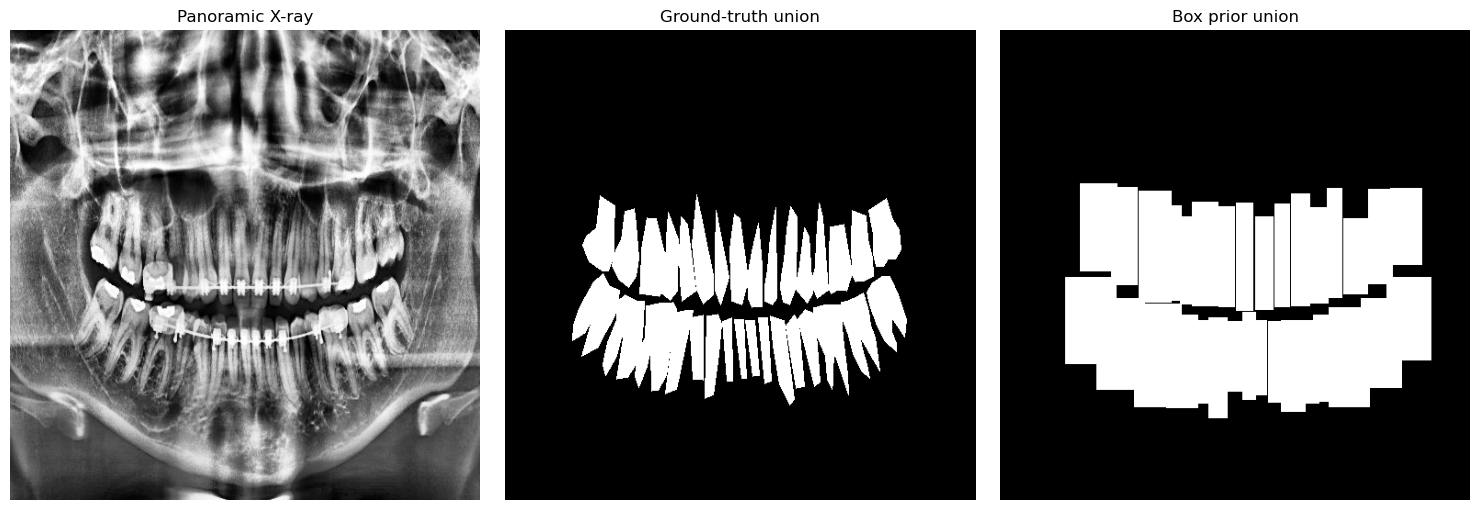

In [7]:
def show_sample(index: int = 0) -> None:
    """展示训练样本的图像、真实分割区域和空间先验。"""
    image = train_x[index]
    mask = train_y[index]
    prior = train_prior[index]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image.squeeze(), cmap="gray")
    axes[0].set_title("Panoramic X-ray")
    axes[1].imshow(mask_union(mask), cmap="gray")
    axes[1].set_title("Ground-truth union")
    axes[2].imshow(mask_union(prior), cmap="gray")
    axes[2].set_title("Box prior union")
    for axis in axes:
        axis.axis("off")
    plt.tight_layout()


show_sample(0)


## 评估指标

使用 Dice 和 IoU 评估二值分割；U-Net 和 OralBBNet 额外统计 32 通道平均 Dice 及牙齿分组 Dice。预测阈值固定为 0.5，训练 metric 的 Dice 阈值为 0.51。


In [8]:
def evaluate_binary(y_true: np.ndarray, y_pred: np.ndarray, threshold: float = PRED_THRESHOLD, epsilon: float = 1e-7) -> Dict[str, float]:
    """计算二值分割的 Dice 和 IoU。y_pred 可以是概率图或多通道概率。"""
    true_bin = mask_union(y_true) > 0
    pred_bin = prediction_union(y_pred) >= threshold

    intersection = np.logical_and(true_bin, pred_bin).sum(dtype=np.float64)
    true_sum = true_bin.sum(dtype=np.float64)
    pred_sum = pred_bin.sum(dtype=np.float64)
    union = np.logical_or(true_bin, pred_bin).sum(dtype=np.float64)

    return {
        "binary_dice": float((2 * intersection + epsilon) / (true_sum + pred_sum + epsilon)),
        "binary_iou": float((intersection + epsilon) / (union + epsilon)),
        "pred_positive_ratio": float(pred_bin.mean()),
    }


def channel_dice(y_true: np.ndarray, y_pred: np.ndarray, threshold: float = PRED_THRESHOLD, epsilon: float = 1e-7) -> np.ndarray:
    """计算每个通道的 Dice 系数，返回长度为通道数的数组。"""
    # Match notebook dice definition: hard threshold and no NaN masking for empty channels.
    true_bin = (y_true > 0).astype(np.float32)
    pred_bin = (y_pred >= threshold).astype(np.float32)
    intersection = np.sum(pred_bin * true_bin, axis=(0, 1), dtype=np.float64)
    pred_sum = np.sum(np.square(pred_bin), axis=(0, 1), dtype=np.float64)
    true_sum = np.sum(np.square(true_bin), axis=(0, 1), dtype=np.float64)
    dice = (2 * intersection + epsilon) / (pred_sum + true_sum + epsilon)
    return dice


def evaluate_multichannel(y_true: np.ndarray, y_pred: np.ndarray, threshold: float = PRED_THRESHOLD) -> Dict[str, float]:
    """计算多通道和牙位分组的平均 Dice。"""
    dices = np.asarray([channel_dice(t, p, threshold=threshold) for t, p in zip(y_true, y_pred)])
    metrics = {"mean_channel_dice": float(np.mean(dices))}
    for group_name, indices in TOOTH_GROUPS.items():
        metrics[f"{group_name}_dice"] = float(np.mean(dices[:, indices]))
    return metrics


def average_metric_dicts(items: Sequence[Dict[str, float]]) -> Dict[str, float]:
    """对多个样本的指标字典求平均。"""
    keys = sorted({key for item in items for key in item})
    return {key: float(np.nanmean([item.get(key, np.nan) for item in items])) for key in keys}


def evaluate_prediction_set(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    method_name: str,
    include_multichannel: bool,
    threshold: float = PRED_THRESHOLD,
) -> Dict[str, float | str]:
    """对一组预测结果计算完整评估指标。"""
    binary_items = [evaluate_binary(t, p, threshold=threshold) for t, p in zip(y_true, y_pred)]
    row: Dict[str, float | str] = {"method": method_name, "threshold": float(threshold), **average_metric_dicts(binary_items)}
    if include_multichannel:
        row.update(evaluate_multichannel(y_true, y_pred, threshold=threshold))
    return row


def summarize_predictions(name: str, pred: np.ndarray, threshold: float = PRED_THRESHOLD) -> None:
    """打印预测概率范围和二值化后的阳性比例，快速判断全黑/全白。"""
    union_prob = np.asarray([prediction_union(p) for p in pred])
    print(
        f"{name}: prob min/mean/max="
        f"{union_prob.min():.4f}/{union_prob.mean():.4f}/{union_prob.max():.4f}, "
        f"positive_ratio@{threshold:.2f}={(union_prob >= threshold).mean():.4f}"
    )

def predict_in_chunks(model: keras.Model, inputs: np.ndarray, chunk_size: int = 8, batch_size: int = 1) -> np.ndarray:
    """分块预测，避免 Keras 在 GPU 上一次性拼接完整测试集导致 OOM。"""
    outputs = []
    for start in range(0, len(inputs), chunk_size):
        end = min(start + chunk_size, len(inputs))
        print(f"Predicting samples {start}:{end} / {len(inputs)}")
        outputs.append(model.predict(inputs[start:end], batch_size=batch_size, verbose=0))
    return np.concatenate(outputs, axis=0)



## 方法一：Active Contour

传统无监督基线：Otsu 初始化、Chan-Vese 分割、形态学后处理。


In [9]:
def largest_components(binary: np.ndarray, keep: int = 32) -> np.ndarray:
    """保留面积最大的若干连通域，减少小噪声。"""
    labeled = measure.label(binary)
    regions = sorted(measure.regionprops(labeled), key=lambda region: region.area, reverse=True)
    cleaned = np.zeros_like(binary, dtype=bool)
    for region in regions[:keep]:
        cleaned[labeled == region.label] = True
    return cleaned


def run_active_contour(image: np.ndarray) -> np.ndarray:
    """
    对单张 X 光片运行 Active Contour 分割。
    流程包括平滑、Otsu 初始化、Chan-Vese 优化和连通域后处理。
    """
    gray = image.squeeze().astype(np.float32)
    gray = (gray - gray.min()) / (gray.max() - gray.min() + 1e-7)
    smooth = filters.gaussian(gray, sigma=1.2)

    # 用 Otsu 阈值生成初始轮廓
    thresh = filters.threshold_otsu(smooth)
    init = smooth > thresh
    init = morphology.binary_closing(init, morphology.disk(5))
    init = morphology.remove_small_objects(init, min_size=64)

    # 兼容不同 scikit-image 版本中的参数命名
    try:
        contour = segmentation.chan_vese(
            smooth,
            mu=0.18,
            lambda1=1.0,
            lambda2=1.0,
            tol=1e-3,
            max_num_iter=120,
            init_level_set=init,
            extended_output=False,
        )
    except TypeError:
        contour = segmentation.chan_vese(
            smooth,
            mu=0.18,
            lambda1=1.0,
            lambda2=1.0,
            tol=1e-3,
            max_iter=120,
            init_level_set=init,
            extended_output=False,
        )

    # 后处理以减少孤立噪声区域
    contour = morphology.remove_small_objects(contour.astype(bool), min_size=64)
    contour = morphology.binary_closing(contour, morphology.disk(3))
    contour = largest_components(contour, keep=32)
    return contour.astype(np.float32)


# 在测试集上运行传统方法基线
print(f"Running Active Contour on {len(test_x)} test images...")
active_predictions = np.asarray([run_active_contour(image) for image in test_x], dtype=np.float32)
print("Active contour predictions:", active_predictions.shape, "non-empty:", int(active_predictions.sum() > 0))


Running Active Contour on 82 test images...
Active contour predictions: (82, 512, 512) non-empty: 1


## 方法二：U-Net

U-Net 仅输入 X 光图像，输出 32 通道 softmax 概率图。模型结构和 loss 与原始 `notebooks/Unet` 保持一致。


In [10]:
def dice_loss_with_l2_regularization(target, predicted, epsilon=1e-7, l2_weight=0.1):
    """原始 Dice + L2 loss。"""
    target = tf.cast(target, tf.float32)
    predicted = tf.cast(predicted, tf.float32)
    intersection = tf.reduce_sum(predicted * target, axis=[1, 2])
    predicted_square = tf.square(predicted)
    target_square = tf.square(target)
    union = tf.reduce_sum(predicted_square, axis=[1, 2]) + tf.reduce_sum(target_square, axis=[1, 2])
    dice = (2 * intersection + epsilon) / (union + epsilon)
    mean_dice_loss = tf.reduce_mean(dice)

    l2_norm = tf.reduce_sum(tf.square(predicted - target), axis=[1, 2])
    l2_regularization = l2_weight * tf.reduce_mean(l2_norm)

    total_loss = mean_dice_loss + l2_regularization
    return total_loss


def dice_coef(target, predicted, epsilon=1e-7):
    """原始固定阈值 Dice。"""
    target = tf.cast(target, tf.float32)
    predicted = tf.cast(predicted, tf.float32)
    predicted = tf.where(predicted < 0.51, 0.00, 1.00)
    intersection = tf.reduce_sum(predicted * target, axis=[1, 2])
    predicted_square = tf.square(predicted)
    target_square = tf.square(target)
    union = tf.reduce_sum(predicted_square, axis=[1, 2]) + tf.reduce_sum(target_square, axis=[1, 2])
    dice = (2 * intersection + epsilon) / (union + epsilon)
    mean_dice_loss = -tf.reduce_mean(dice)
    return -mean_dice_loss


segmentation_loss = dice_loss_with_l2_regularization


class ReduceLearningRate(keras.callbacks.Callback):
    """原始学习率衰减回调。"""
    def __init__(self, monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1):
        super().__init__()
        self.monitor = monitor
        self.factor = factor
        self.patience = patience
        self.min_lr = min_lr
        self.verbose = verbose
        self.wait = 0
        self.best_loss = float("inf")
        self.reduce_lr = self.min_lr

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current_loss = logs.get(self.monitor)
        if current_loss is None:
            raise ValueError(f"Monitoring metric '{self.monitor}' is not available.")

        if current_loss < self.best_loss:
            self.best_loss = current_loss
            self.wait = 0
            self.reduce_lr = self.model.optimizer.learning_rate
        else:
            self.wait += 1
            if self.wait >= self.patience:
                if self.reduce_lr > self.min_lr:
                    self.reduce_lr = self.reduce_lr * self.factor
                    self.model.optimizer.learning_rate.assign(self.reduce_lr)
                    if self.verbose > 0:
                        print(f"\nEpoch {epoch + 1}: Reducing learning rate to {self.reduce_lr}")
                self.wait = 0



def conv_block(x, filters: int, drop_rate: float = 0.12):
    """Conv → ReLU → BN → SpatialDropout block。"""
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.Activation("relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.SpatialDropout2D(drop_rate)(x)
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.Activation("relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.SpatialDropout2D(drop_rate)(x)
    return x


def make_dataset(
    x_array: np.ndarray,
    y_array: np.ndarray,
    input_shape: Tuple[int, ...],
    shuffle: bool,
    batch_size: int = GLOBAL_BATCH_SIZE,
    augment: bool = False,
) -> tf.data.Dataset:
    """构建训练 Dataset。"""
    def generator():
        for x, y in zip(x_array, y_array):
            x = x.astype(np.float32)
            y = y.astype(np.float32)
            if augment:
                if np.random.uniform() > 0.5:
                    x = np.flip(x, axis=1).copy()
                    y = np.flip(y, axis=1).copy()
                if np.random.uniform() > 0.5:
                    x = np.flip(x, axis=0).copy()
                    y = np.flip(y, axis=0).copy()
            yield x, y

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=input_shape, dtype=tf.float32),
            tf.TensorSpec(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], OUTPUT_CHANNELS), dtype=tf.float32),
        ),
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=min(1024, len(x_array)), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.repeat().batch(batch_size, drop_remainder=False).prefetch(tf.data.AUTOTUNE)

    options = tf.data.Options()
    options.experimental_distribute.auto_shard_policy = tf.data.experimental.AutoShardPolicy.OFF
    return ds.with_options(options)


def compile_segmentation_model(model: keras.Model, learning_rate: float = LEARNING_RATE) -> keras.Model:
    """按原始设置编译模型。"""
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate, beta_1=ADAM_BETA_1),
        loss=segmentation_loss,
        metrics=[keras.metrics.Precision(), keras.metrics.Recall(), dice_coef],
    )
    return model


def train_model(
    model: keras.Model,
    train_inputs: np.ndarray,
    train_targets: np.ndarray,
    valid_inputs: np.ndarray,
    valid_targets: np.ndarray,
    input_shape: Tuple[int, ...],
    model_name: str,
    epochs: int = EPOCHS,
    batch_size: int = GLOBAL_BATCH_SIZE,
    accumulation_steps: int = EFFECTIVE_ACCUMULATION_STEPS,
):
    """训练并保存最佳权重；支持梯度累积模拟 batch=2。"""
    steps_per_epoch = int(np.ceil(len(train_inputs) / batch_size))
    validation_steps = int(np.ceil(len(valid_inputs) / batch_size))
    print(
        f"{model_name}: physical_batch={batch_size}, accumulation_steps={accumulation_steps}, "
        f"effective_batch={batch_size * accumulation_steps}, steps_per_epoch={steps_per_epoch}, "
        f"validation_steps={validation_steps}"
    )

    train_ds = make_dataset(
        train_inputs,
        train_targets,
        input_shape=input_shape,
        shuffle=False,
        batch_size=batch_size,
        augment=TRAIN_AUGMENT_FLIPS,
    )
    valid_ds = make_dataset(
        valid_inputs,
        valid_targets,
        input_shape=input_shape,
        shuffle=False,
        batch_size=batch_size,
        augment=False,
    )

    best_weights_path = CHECKPOINT_DIR / f"{model_name.lower()}_best.weights.h5"
    if USE_MIRRORED_STRATEGY:
        lr_callback = ReduceLearningRate(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)
        callbacks = [
            lr_callback,
            keras.callbacks.ModelCheckpoint(
                filepath=str(best_weights_path),
                monitor="val_loss",
                save_best_only=True,
                save_weights_only=True,
                mode="min",
                verbose=1,
            ),
            keras.callbacks.CSVLogger(str(RESULTS_DIR / f"{model_name.lower()}_history.csv")),
        ]
        history_obj = model.fit(
            train_ds,
            validation_data=valid_ds,
            epochs=epochs,
            steps_per_epoch=steps_per_epoch,
            validation_steps=validation_steps,
            callbacks=callbacks,
            verbose=1,
        )
        if best_weights_path.exists():
            model.load_weights(str(best_weights_path))
        best_val_loss = float(np.nanmin(np.asarray(history_obj.history.get("val_loss", [np.nan]), dtype=np.float32)))
        print(f"Loaded best {model_name} weights from {best_weights_path} (val_loss={best_val_loss:.6f})")
        return history_obj.history, best_weights_path, best_val_loss

    optimizer = model.optimizer
    loss_fn = model.loss
    accum_grads = [tf.Variable(tf.zeros_like(var), trainable=False) for var in model.trainable_variables]

    @tf.function
    def train_step(x, y):
        with tf.GradientTape() as tape:
            pred = model(x, training=True)
            loss = loss_fn(y, pred)
        grads = tape.gradient(loss, model.trainable_variables)
        for i, grad in enumerate(grads):
            if grad is not None:
                accum_grads[i].assign_add(grad)
        return loss

    @tf.function
    def apply_accumulated_grads(actual_steps):
        scaled = [grad / tf.cast(actual_steps, tf.float32) for grad in accum_grads]
        optimizer.apply_gradients(zip(scaled, model.trainable_variables))
        for grad in accum_grads:
            grad.assign(tf.zeros_like(grad))

    @tf.function
    def valid_step(x, y):
        pred = model(x, training=False)
        return loss_fn(y, pred)

    history = {"loss": [], "val_loss": []}
    best_val_loss = float("inf")
    wait = 0

    train_iter = iter(train_ds)
    valid_iter = iter(valid_ds)
    for epoch in range(epochs):
        train_losses = []
        step_in_acc = 0
        for _ in range(steps_per_epoch):
            bx, by = next(train_iter)
            loss = train_step(bx, by)
            train_losses.append(float(loss))
            step_in_acc += 1
            if step_in_acc == accumulation_steps:
                apply_accumulated_grads(step_in_acc)
                step_in_acc = 0
        if step_in_acc:
            apply_accumulated_grads(step_in_acc)

        val_losses = []
        for _ in range(validation_steps):
            vx, vy = next(valid_iter)
            val_losses.append(float(valid_step(vx, vy)))

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        history["loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        print(f"Epoch {epoch + 1}/{epochs} - loss: {train_loss:.6f} - val_loss: {val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            wait = 0
            model.save_weights(best_weights_path)
            print(f"saved best weights -> {best_weights_path}")
        else:
            wait += 1
            if wait >= 5:
                current_lr = float(optimizer.learning_rate.numpy())
                new_lr = max(current_lr * 0.5, 1e-6)
                optimizer.learning_rate.assign(new_lr)
                print(f"Reducing learning rate to {new_lr}")
                wait = 0

    if best_weights_path.exists():
        model.load_weights(str(best_weights_path))
    pd.DataFrame(history).to_csv(RESULTS_DIR / f"{model_name.lower()}_history.csv", index=False)
    print(f"Loaded best {model_name} weights from {best_weights_path} (val_loss={best_val_loss:.6f})")
    return history, best_weights_path, best_val_loss


In [11]:
def build_unet_model(
    img_size: Tuple[int, int] = IMAGE_SIZE,
    num_classes: int = OUTPUT_CHANNELS,
    base_filters: int = BASE_FILTERS,
) -> keras.Model:
    """
    构建 U-Net 分割模型。
    编码器通道数由 BASE_FILTERS 控制。默认 64→128→256→512→1024，与 notebooks 中 U-Net 一致。
    输出: 1x1 卷积 + softmax → 32 通道掩码
    """
    inputs = keras.Input(shape=img_size + (1,), name="xray")

    # 编码器
    skip_connections = []
    x = conv_block(inputs, base_filters)
    skip_connections.append(x)

    for filters in [base_filters * 2, base_filters * 4, base_filters * 8, base_filters * 16]:
        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)
        x = conv_block(x, filters)
        skip_connections.append(x)

    # 最深层特征作为 bottleneck，不参与 skip 拼接
    skip_connections.pop()

    # 解码器
    for filters in [base_filters * 8, base_filters * 4, base_filters * 2]:
        x = layers.Conv2DTranspose(filters, 3, strides=2, padding="same")(x)
        x = layers.Activation("relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.SpatialDropout2D(0.12)(x)
        x = layers.concatenate([x, skip_connections.pop()])
        x = conv_block(x, filters)

    # 恢复到输入分辨率
    x = layers.Conv2DTranspose(base_filters, 3, strides=2, padding="same")(x)
    x = layers.Activation("relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.SpatialDropout2D(0.12)(x)
    x = layers.concatenate([x, skip_connections.pop()])
    x = conv_block(x, base_filters)

    outputs = layers.Conv2D(num_classes, 1, activation="softmax", padding="same", name="mask", dtype="float32")(x)
    return keras.Model(inputs, outputs, name="UNet")


with strategy.scope():
    unet_model = compile_segmentation_model(build_unet_model())

unet_model.summary()


Model: "UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ xray (InputLayer)   │ (None, 512, 512,  │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │        640 │ xray[0][0]        │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 512, 512,  │          0 │ conv2d[0][0]      │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512, 512,  │        256 │ activation[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 512, 512,  │     36,928 │ spatial_dropout2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 512, 512,  │          0 │ conv2d_1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        256 │ activation_1[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_1 │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ spatial_dropout2… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 256, 256,  │          0 │ conv2d_2[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        512 │ activation_2[0][… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_2 │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (SpatialDropout2D)  │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 256,  │    147,584 │ spatial_dropout2… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 256, 256,  │          0 │ conv2d_3[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        512 │ activation_3[0][

 Total params: 34,541,600 (131.77 MB)

 Trainable params: 34,527,904 (131.71 MB)

 Non-trainable params: 13,696 (53.50 KB)

In [12]:
# 训练 U-Net，固定阈值评估。
unet_history, unet_best_weights_path, unet_best_val_loss = train_model(
    model=unet_model,
    train_inputs=train_x,
    train_targets=train_y,
    valid_inputs=valid_x,
    valid_targets=valid_y,
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 1),
    model_name="UNet",
    epochs=EPOCHS,
)

unet_threshold = PRED_THRESHOLD
print("Generating U-Net test predictions with best weights...")
unet_pred = predict_in_chunks(unet_model, test_x, chunk_size=8, batch_size=1)
summarize_predictions("U-Net test", unet_pred, threshold=unet_threshold)
print("U-Net pred shape:", unet_pred.shape)


UNet: physical_batch=2, accumulation_steps=1, effective_batch=2, steps_per_epoch=157, validation_steps=15


I0000 00:00:1779690218.678245 3507647 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

E0000 00:00:1779690233.842574 3507647 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/UNet_1/spatial_dropout2d_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1779690237.865076 3508259 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1779690240.344870 3508254 cuda_dnn.cc:461] Loaded cuDNN version 92200


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coef: 0.0592 - loss: 381.8111 - precision: 0.0292 - recall: 0.0015

...


Epoch 1: val_loss improved from None to 313.27106, saving model to /oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/results_original/checkpoints/unet_best.weights.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 397s 2s/step - dice_coef: 0.1205 - loss: 344.4631 - precision: 0.0277 - recall: 7.0970e-04 - val_dice_coef: 0.1552 - val_loss: 313.2711 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/60
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coef: 0.0584 - loss: 354.0940 - precision: 0.0279 - recall: 1.8882e-04
Epoch 2: val_loss improved from 313.27106 to 312.41922, saving model to /oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/results_original/checkpoints/unet_best.weights.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 394s 3s/step - dice_coef: 0.1191 - loss: 333.1455 - precision: 0.0331 - recall: 2.2915e-04 - val_dice_coef: 0.1562 - val_loss: 312.4192 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/60
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coef: 0.0588 - loss: 353.3068 - pre

W0000 00:00:1779695581.748106 3508253 local_rendezvous.cc:412] Local rendezvous is aborting with status: CANCELLED: GetNextFromShard was cancelled
	 [[{{node MultiDeviceIteratorGetNextFromShard}}]]
	 [[RemoteCall]] [type.googleapis.com/tensorflow.DerivedStatus='']


Loaded best UNet weights from /oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/results_original/checkpoints/unet_best.weights.h5 (val_loss=210.606613)
Generating U-Net test predictions with best weights...
Predicting samples 0:8 / 82


W0000 00:00:1779695584.512318 3507647 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: goo.gle/debugonly    op: "Conv2DBackpropInput" attr { key: "T" value { type: DT_FLOAT } } attr { key: "data_format" value { s: "NCHW" } } attr { key: "dilations" value { list { i: 1 i: 1 i: 1 i: 1 } } } attr { key: "explicit_paddings" value { list { } } } attr { key: "padding" value { s: "SAME" } } attr { key: "strides" value { list { i: 1 i: 1 i: 2 i: 2 } } } attr { key: "use_cudnn_on_gpu" value { b: true } } inputs { dtype: DT_INT32 shape { dim { size: 4 } } } inputs { dtype: DT_FLOAT shape { dim { size: 3 } dim { size: 3 } dim { size: 512 } dim { size: 1024 } } } inputs { dtype: DT_FLOAT shape { dim { } dim { size: 1024 } dim { size: 32 } dim { size: 32 } } } device { type: "GPU" vendor: "NVIDIA" model: "NVIDIA GeForce RTX 3090" frequency: 1695 num_cores: 82 environment { key: "architecture" value: "8.6" } environment { key: "cuda" value: "12050" } environment { key: "cudnn" valu

Predicting samples 8:16 / 82
Predicting samples 16:24 / 82
Predicting samples 24:32 / 82
Predicting samples 32:40 / 82
Predicting samples 40:48 / 82
Predicting samples 48:56 / 82
Predicting samples 56:64 / 82
Predicting samples 64:72 / 82
Predicting samples 72:80 / 82
Predicting samples 80:82 / 82
U-Net test: prob min/mean/max=0.0325/0.1408/1.0000, positive_ratio@0.50=0.1172
U-Net pred shape: (82, 512, 512, 32)


## 方法三：OralBBNet

OralBBNet 在 U-Net skip connection 中加入 YOLO 边界框先验，用空间提示约束分割区域。


### YOLO 标签先验

将 YOLO 标签中的归一化框转换为 512×512 的 32 通道矩形先验。


In [15]:
def build_oralbbnet_model(
    img_size: Tuple[int, int] = IMAGE_SIZE,
    num_classes: int = OUTPUT_CHANNELS,
    base_filters: int = BASE_FILTERS,
) -> keras.Model:
    """
    构建带边界框先验的 OralBBNet 分割模型。
    
    输入包含 num_classes + 1 个通道：
    - 前 num_classes 通道：空间边界框先验（每个牙齿类别一个二值通道）
    - 最后一通道：X 光图像
    
    先验分支下采样到不同尺度后，对 U-Net 的 skip connection 进行门控。
    """
    inputs = keras.Input(shape=img_size + (num_classes + 1,), name="box_prior_plus_xray")
    box_inputs = inputs[..., :num_classes]       # 边界框先验 (32 通道)
    image_inputs = inputs[..., num_classes:]      # X 光图像 (1 通道)

    # 图像编码器
    skip_connections = []
    x = conv_block(image_inputs, base_filters)
    skip_connections.append(x)

    for filters in [base_filters * 2, base_filters * 4, base_filters * 8, base_filters * 16]:
        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)
        x = conv_block(x, filters)
        skip_connections.append(x)

    # 多尺度先验门控分支
    bb_out = []
    for idx, filters in enumerate([base_filters, base_filters * 2, base_filters * 4, base_filters * 8]):
        stride = 2 ** idx
        if idx == 0:
            stride = 1  # 第一层不下采样
        bb = layers.MaxPooling2D(pool_size=(stride, stride), strides=stride)(box_inputs) if stride > 1 else box_inputs
        bb = layers.Conv2D(filters, 3, padding="same")(bb)
        bb = layers.Conv2D(filters, 3, padding="same", activation="softmax")(bb)
        bb_out.append(bb)

    # 解码器
    skip_connections.pop()  # 移除最深层特征
    for filters in [base_filters * 8, base_filters * 4, base_filters * 2]:
        x = layers.Conv2DTranspose(filters, 3, strides=2, padding="same")(x)
        x = layers.Activation("relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.SpatialDropout2D(0.12)(x)
        skip_connection = skip_connections.pop()
        bb_layer = bb_out.pop()
        gated_skip = layers.Multiply()([skip_connection, bb_layer])
        x = layers.concatenate([x, gated_skip])
        x = conv_block(x, filters)

    # 恢复到输入分辨率
    x = layers.Conv2DTranspose(base_filters, 3, strides=2, padding="same")(x)
    x = layers.Activation("relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.SpatialDropout2D(0.12)(x)
    skip_connection = skip_connections.pop()
    bb_layer = bb_out.pop()
    gated_skip = layers.Multiply()([skip_connection, bb_layer])
    x = layers.concatenate([x, gated_skip])
    x = conv_block(x, base_filters)

    outputs = layers.Conv2D(num_classes, 1, activation="softmax", padding="same", name="mask", dtype="float32")(x)
    return keras.Model(inputs, outputs, name="OralBBNet")


with strategy.scope():
    oralbbnet_model = compile_segmentation_model(build_oralbbnet_model())

oralbbnet_model.summary()


Model: "OralBBNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ box_prior_plus_xray │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 33)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 512, 512,  │          0 │ box_prior_plus_x… │
│ (GetItem)           │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_54 (Conv2D)  │ (None, 512, 512,  │        640 │ get_item_5[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_44       │ (None, 512, 512,  │          0 │ conv2d_54[0][0]   │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        256 │ activation_44[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_… │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_55 (Conv2D)  │ (None, 512, 512,  │     36,928 │ spatial_dropout2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_45       │ (None, 512, 512,  │          0 │ conv2d_55[0][0]   │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        256 │ activation_45[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_… │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_18    │ (None, 256, 256,  │          0 │ spatial_dropout2… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_56 (Conv2D)  │ (None, 256, 256,  │     73,856 │ max_pooling2d_18… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_46       │ (None, 256, 256,  │          0 │ conv2d_56[0][0]   │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        512 │ activation_46[0]… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_… │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (SpatialDropout2D)  │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_57 (Conv2D)  │ (None, 256, 256,  │    147,584 │ spatial_dropout2… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_47       │ (None, 256, 256,  │          0 │ conv2d_57[0][0] 

 Total params: 37,953,440 (144.78 MB)

 Trainable params: 37,939,744 (144.73 MB)

 Non-trainable params: 13,696 (53.50 KB)

In [16]:
# 训练 OralBBNet，固定阈值评估。
oralbbnet_history, oralbbnet_best_weights_path, oralbbnet_best_val_loss = train_model(
    model=oralbbnet_model,
    train_inputs=oral_train_x,
    train_targets=train_y,
    valid_inputs=oral_valid_x,
    valid_targets=valid_y,
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], OUTPUT_CHANNELS + 1),
    model_name="OralBBNet",
    epochs=EPOCHS,
)

oralbbnet_threshold = PRED_THRESHOLD
print("Generating OralBBNet test predictions with best weights...")
oralbbnet_pred = predict_in_chunks(oralbbnet_model, oral_test_x, chunk_size=8, batch_size=1)
summarize_predictions("OralBBNet test", oralbbnet_pred, threshold=oralbbnet_threshold)
print("OralBBNet pred shape:", oralbbnet_pred.shape)


OralBBNet: physical_batch=2, accumulation_steps=1, effective_batch=2, steps_per_epoch=157, validation_steps=15
Epoch 1/60
INFO:tensorflow:Collective all_reduce tensors: 106 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


E0000 00:00:1779695897.619261 3507647 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/OralBBNet_1/spatial_dropout2d_44_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - dice_coef: 0.0545 - loss: 381.9881 - precision_1: 0.0250 - recall_1: 0.0017
Epoch 1: val_loss improved from None to 1840.45679, saving model to /oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/results_original/checkpoints/oralbbnet_best.weights.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 56s 221ms/step - dice_coef: 0.1148 - loss: 345.4010 - precision_1: 0.0218 - recall_1: 0.0010 - val_dice_coef: 0.0894 - val_loss: 1840.4568 - val_precision_1: 0.0054 - val_recall_1: 0.0317
Epoch 2/60
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - dice_coef: 0.0601 - loss: 353.5730 - precision_1: 0.0838 - recall_1: 0.0018
Epoch 2: val_loss improved from 1840.45679 to 388.81296, saving model to /oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/results_original/checkpoints/oralbbnet_best.weights.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 35s 226ms/step - dice_coef: 0.1244 - loss: 330.0071 - precision_1: 0.2729 - recall_1: 0.0071 - val_dice_coef: 0.1188 - val_loss: 388.8130 - val_prec

W0000 00:00:1779698152.987531 3508211 local_rendezvous.cc:412] Local rendezvous is aborting with status: CANCELLED: GetNextFromShard was cancelled
	 [[{{node MultiDeviceIteratorGetNextFromShard}}]]
	 [[RemoteCall]] [type.googleapis.com/tensorflow.DerivedStatus='']


Loaded best OralBBNet weights from /oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/results_original/checkpoints/oralbbnet_best.weights.h5 (val_loss=172.236389)
Generating OralBBNet test predictions with best weights...
Predicting samples 0:8 / 82


W0000 00:00:1779698155.571341 3507647 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: goo.gle/debugonly    op: "Conv2D" attr { key: "T" value { type: DT_FLOAT } } attr { key: "data_format" value { s: "NCHW" } } attr { key: "dilations" value { list { i: 1 i: 1 i: 1 i: 1 } } } attr { key: "explicit_paddings" value { list { } } } attr { key: "padding" value { s: "SAME" } } attr { key: "strides" value { list { i: 1 i: 1 i: 1 i: 1 } } } attr { key: "use_cudnn_on_gpu" value { b: true } } inputs { dtype: DT_FLOAT shape { dim { } dim { size: 32 } dim { size: 512 } dim { size: 512 } } } inputs { dtype: DT_FLOAT shape { dim { size: 3 } dim { size: 3 } dim { size: 32 } dim { size: 64 } } } device { type: "GPU" vendor: "NVIDIA" model: "NVIDIA GeForce RTX 3090" frequency: 1695 num_cores: 82 environment { key: "architecture" value: "8.6" } environment { key: "cuda" value: "12050" } environment { key: "cudnn" value: "90300" } num_registers: 65536 l1_cache_size: 24576 l2_cache_size:

Predicting samples 8:16 / 82
Predicting samples 16:24 / 82
Predicting samples 24:32 / 82
Predicting samples 32:40 / 82
Predicting samples 40:48 / 82
Predicting samples 48:56 / 82
Predicting samples 56:64 / 82
Predicting samples 64:72 / 82
Predicting samples 72:80 / 82
Predicting samples 80:82 / 82
OralBBNet test: prob min/mean/max=0.0317/0.1742/1.0000, positive_ratio@0.50=0.1629
OralBBNet pred shape: (82, 512, 512, 32)


## 定量结果

汇总测试集指标，并保存到 `results/metrics.csv`。


In [17]:
# 测试集指标
metrics_rows = [
    evaluate_prediction_set(test_y, active_predictions[..., np.newaxis], "Active Contour", include_multichannel=False, threshold=0.5),
    evaluate_prediction_set(test_y, unet_pred, "U-Net", include_multichannel=True, threshold=unet_threshold),
    evaluate_prediction_set(test_y, oralbbnet_pred, "OralBBNet", include_multichannel=True, threshold=oralbbnet_threshold),
]

metrics_df = pd.DataFrame(metrics_rows)
metrics_path = RESULTS_DIR / "metrics.csv"
metrics_df.to_csv(metrics_path, index=False)
print(f"Metrics saved to {metrics_path}")
metrics_df


Metrics saved to /oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/results_original/metrics.csv


,method,threshold,binary_dice,binary_iou,pred_positive_ratio,mean_channel_dice,incisors_dice,canines_dice,premolars_dice,molars_dice
0,Active Contour,0.5,0.349520,0.215066,0.788588,NaN,NaN,NaN,NaN,NaN
1,U-Net,0.5,0.715886,0.568386,0.117243,0.436078,0.406695,0.500069,0.472757,0.409884
2,OralBBNet,0.5,0.863119,0.768472,0.162881,0.755875,0.705041,0.770332,0.752047,0.787497


,dice_coef,loss,precision,recall,val_dice_coef,val_loss,val_precision,val_recall
55,0.593237,176.271774,0.757960,0.601072,0.481200,226.003433,0.577547,0.459271
56,0.595752,174.903381,0.763136,0.603613,0.495573,226.175812,0.577445,0.467554
57,0.603641,172.138885,0.769204,0.610885,0.503453,223.740097,0.583821,0.477153
58,0.609841,170.152222,0.775403,0.620093,0.481706,227.640381,0.567408,0.461651
59,0.616875,167.670868,0.778911,0.629810,0.512162,219.740662,0.596818,0.492637


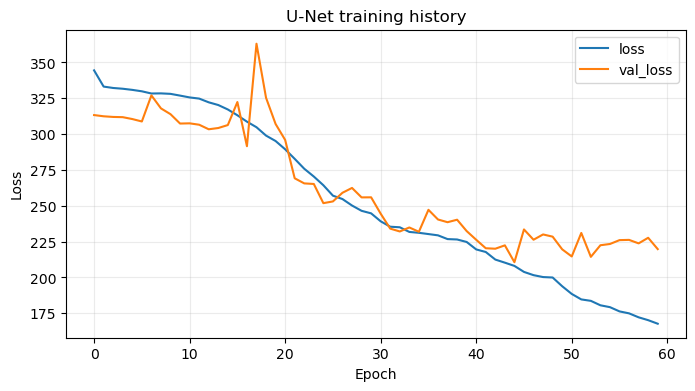

,dice_coef,loss,precision_1,recall_1,val_dice_coef,val_loss,val_precision_1,val_recall_1
55,0.681562,143.663010,0.831303,0.713861,0.653312,175.015640,0.721723,0.639620
56,0.682223,143.611420,0.830806,0.714333,0.658307,175.520645,0.713127,0.643916
57,0.684581,143.396973,0.831577,0.715640,0.646100,172.236389,0.732193,0.634110
58,0.687029,145.145325,0.825550,0.713490,0.581284,175.113297,0.725127,0.628953
59,0.689905,142.197845,0.832963,0.719868,0.593120,172.933029,0.743970,0.603339


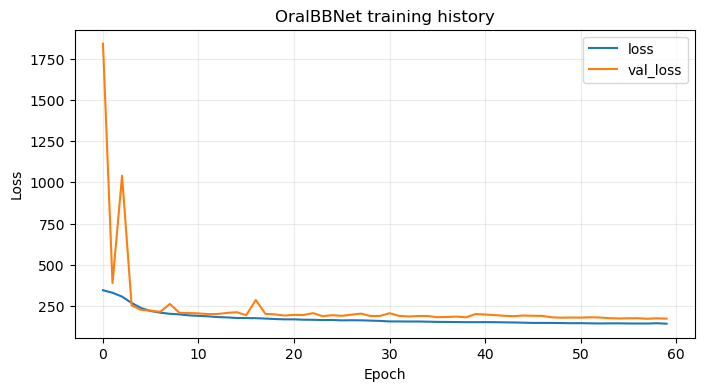

In [18]:
def plot_training_history(history, title: str) -> None:
    """绘制训练集和验证集 loss 曲线。"""
    if history is None:
        print(f"Warning: {title} history is not available")
        return
    history_df = pd.DataFrame(history)
    display(history_df.tail())
    ax = history_df[[column for column in history_df.columns if "loss" in column]].plot(figsize=(8, 4), title=title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    plt.grid(alpha=0.25)
    plt.show()


plot_training_history(unet_history, "U-Net training history")
plot_training_history(oralbbnet_history, "OralBBNet training history")


## 定性结果

展示测试样本的真实 mask、概率热图和阈值化预测图。


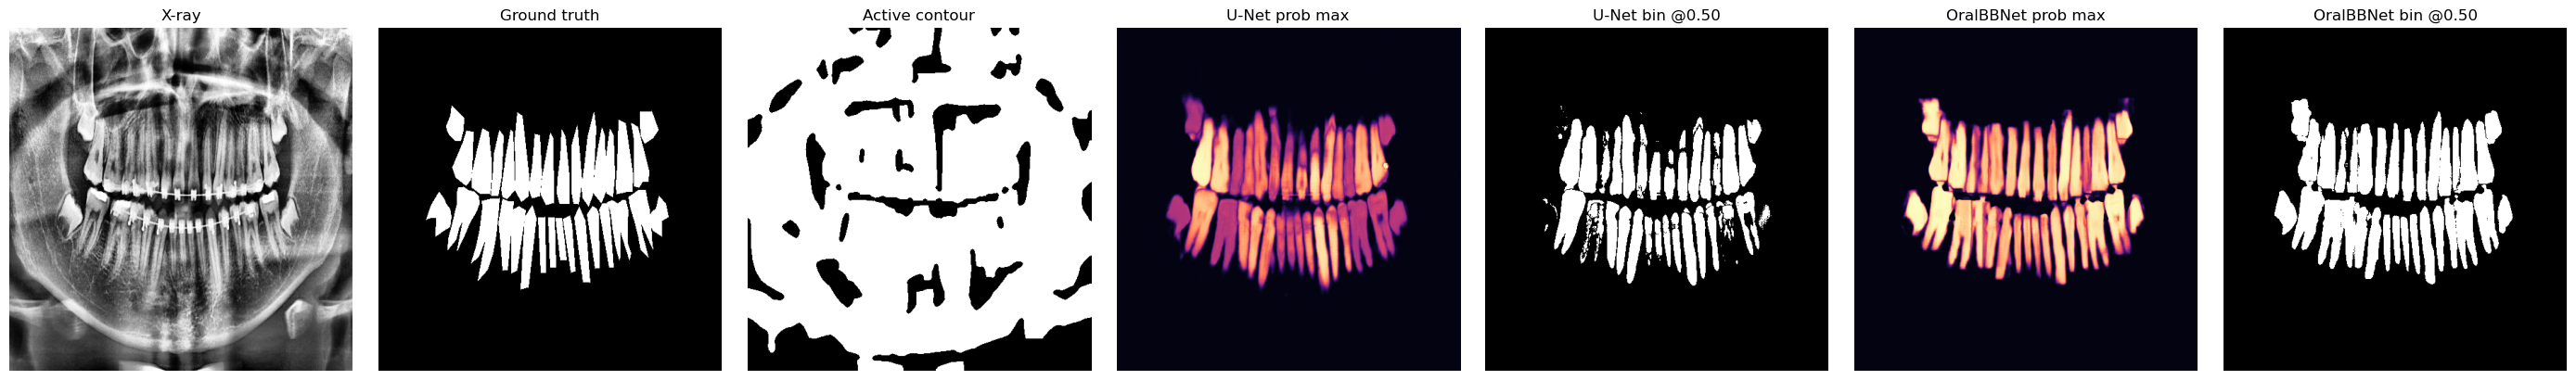

Saved qualitative figure to /oral_llm/xiweidai/dentalagent2/Instance_seg_teeth/results_original/qualitative_examples.png


In [19]:
def plot_qualitative_results(
    index: int = 0,
    save_path: Path = RESULTS_DIR / "qualitative_examples.png",
) -> None:
    """绘制测试样本的定性对比结果。"""
    image = test_x[index]
    gt = test_y[index]
    active = active_predictions[index]
    unet_prob = prediction_union(unet_pred[index])
    oral_prob = prediction_union(oralbbnet_pred[index])
    unet_bin = binarize_prediction(unet_pred[index], threshold=unet_threshold)
    oral_bin = binarize_prediction(oralbbnet_pred[index], threshold=oralbbnet_threshold)

    panels = [
        ("X-ray", image.squeeze(), "gray", None),
        ("Ground truth", mask_union(gt), "gray", None),
        ("Active contour", active, "gray", None),
        (f"U-Net prob max", unet_prob, "magma", (0.0, 1.0)),
        (f"U-Net bin @{unet_threshold:.2f}", unet_bin, "gray", None),
        (f"OralBBNet prob max", oral_prob, "magma", (0.0, 1.0)),
        (f"OralBBNet bin @{oralbbnet_threshold:.2f}", oral_bin, "gray", None),
    ]

    fig, axes = plt.subplots(1, len(panels), figsize=(4 * len(panels), 4))
    for axis, (title, data, cmap, limits) in zip(axes, panels):
        kwargs = {"cmap": cmap}
        if limits is not None:
            kwargs.update({"vmin": limits[0], "vmax": limits[1]})
        axis.imshow(data, **kwargs)
        axis.set_title(title)
        axis.axis("off")
    plt.tight_layout()
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved qualitative figure to {save_path}")


plot_qualitative_results(0)


## 实验总结

比较 Active Contour、U-Net 和 OralBBNet 的定量指标与可视化结果，分析边界框先验是否提升分割效果。
